# Notebook 5 (V4_3) — Sample Path with Regime Switch & Baseline Export

Simulate a single history of the regime process from $z_0 = u$:
- stay in $u$ with probability $\pi$;
- switch to $b$ with probability $1 - \pi$;
- once in $b$, remain in $b$ forever (V4_3 absorbing regime).

V4_3 Definition `def_recursive_equilibrium` (line 664) specifies a
Markov competitive equilibrium as measurable functions of the state
$s = (z, N_{US}, N_W)$. The simulated path is generated by evaluating
these equilibrium functions at the realized state at each date,
following the transition map $\Gamma$ (V4_3 eq. `recursive_next_state`,
line 629).

Using the policy maps from notebook 3 (u-branch) and notebook 2 (BGP),
we construct the path of all variables across the regime switch.
**Expected V4_3 result:** the per-variety price-dividend ratio rises
along the u-branch, then becomes constant after the switch — the bubble
collapses when the regime absorbs (V4_3 Proposition
`prop_no_bubble_absorbing_branch`).

This notebook also serves as the **end-to-end baseline export**: §6 below
writes the standard artifacts (three CSVs, four PNG figures, and a
residual report) to `outputs_v43/`. The CSVs use the V4_3 25-column
schema, carrying both the **primary** unknown $\theta_{US,t}^*$
(positive) and the **recovered** US bond share $\theta_t$ (negative),
plus the V4_3 accounting objects $\mathcal I_{US,t}, \mathcal I_{W,t},
\Psi_t$. To regenerate everything headlessly:
`jupyter nbconvert --to notebook --execute 05_v9_simulation_path.ipynb`.


**HKT replication.** With the HKT-matched benchmark (`ProductionParams(T_max=100)`) and $\tau = 40$, this notebook reproduces the single-country experiment of HKT (arXiv:2501.08215, §4.2): the unbalanced state $u$ persists through $t = 39$ and the economy switches to the absorbing balanced state $b$ at $t = 40$.

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryProductionOLG.jl")
using Plots, LaTeXStrings, Printf, Random
gr()

OUTDIR = "outputs_v43"          # repo-root relative (kernel cwd = project root)
isdir(OUTDIR) || mkdir(OUTDIR)
println("Output directory: ", OUTDIR)


  Activating 

Output directory: outputs_v43

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


In [2]:
p = ProductionParams(T_max=100)   # HKT-matched defaults; solvable to T≈100+
result = run_production_simulation(p; verbose=true)

@printf("u-branch converged: %s   max ‖F_u‖ = %.2e\n",
        result.branch_converged, result.max_u_residual)
@printf("V4_3 equity-weight min slack: %.4e   ok=%s\n",
        result.diagnostics.equity_weight_min, result.diagnostics.equity_weights_ok)
if !result.branch_converged || !(result.max_u_residual < 1e-5)
    @warn "u-branch did not meet the residual tolerance; downstream diagnostics/exports are provisional." max_u_residual=result.max_u_residual
end


Calibrating ν_b for common world growth (V4_3 G_b = G_W)...
  iter  1: ν_b -> 0.094292 (Δ=5.71e-03), ‖F‖=2.15e-12
  iter  2: ν_b -> 0.090367 (Δ=3.93e-03), ‖F‖=4.78e-13
  iter  3: ν_b -> 0.087667 (Δ=2.70e-03), ‖F‖=1.06e-13
  iter  4: ν_b -> 0.085810 (Δ=1.86e-03), ‖F‖=2.36e-14
  iter  5: ν_b -> 0.084532 (Δ=1.28e-03), ‖F‖=5.38e-15
  iter  6: ν_b -> 0.083654 (Δ=8.78e-04), ‖F‖=9.36e-16
  iter  7: ν_b -> 0.083050 (Δ=6.04e-04), ‖F‖=2.22e-16
  iter  8: ν_b -> 0.082634 (Δ=4.16e-04), ‖F‖=4.44e-16
  iter  9: ν_b -> 0.082348 (Δ=2.86e-04), ‖F‖=2.78e-16
  iter 10: ν_b -> 0.082152 (Δ=1.97e-04), ‖F‖=1.35e-16
  iter 11: ν_b -> 0.082017 (Δ=1.35e-04), ‖F‖=4.86e-10
  iter 12: ν_b -> 0.081924 (Δ=9.30e-05), ‖F‖=2.30e-10
  iter 13: ν_b -> 0.081860 (Δ=6.40e-05), ‖F‖=1.09e-10
  iter 14: ν_b -> 0.081816 (Δ=4.40e-05), ‖F‖=5.15e-11
  iter 15: ν_b -> 0.081785 (Δ=3.03e-05), ‖F‖=2.43e-11
  iter 16: ν_b -> 0.081765 (Δ=2.08e-05), ‖F‖=1.15e-11
  iter 17: ν_b -> 0.081750 (Δ=1.43e-05), ‖F‖=5.45e-12
  iter 18: ν_b -> 0.08

┌ Warning: Forward-backward did not fully converge after 30 iters.
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/TwoCountryProductionOLG.jl:1216


Computing bubble diagnostics...
  u-branch converged: true   max ‖F_u‖ = 3.94e-08

══════ V4_3 PRODUCTION-ECONOMY DIAGNOSTICS ══════
  Condition (1a) converges: false   (Σ d^u/q^u  = 5.668957)
  Condition (1b) converges: false   (Σ branch   = 98.573954)
  Geometric-tail (1a): ratio=0.9580  converges=true  Σ_∞=5.832870
  Geometric-tail (1b): ratio=0.9894  converges=true  Σ_∞=161.600374
  BUBBLE EXISTS: true  (tail, regularity, and residual checks)
  Total leakage Σ a_t = 47.914937
  V4_3 ass_regular_kernel  Ψ_t > 0: true  (min Ψ = 9.8357e-01)
  V4_3 ass_interior_equity_weights: true  (min slack = 2.4448e-02)
u-branch converged: true   max ‖F_u‖ = 3.94e-08
V4_3 equity-weight min slack: 2.4448e-02   ok=true


## 1. Construct a Sample Path with a Specified Switch Date

In [3]:
# Switch date τ: economy is in u for t < τ, in b for t ≥ τ.
# build_switch_path is defined in TwoCountryProductionOLG.jl and advances
# post-switch knowledge with absorbing-branch allocations.
τ_switch = 40   # HKT replication (arXiv:2501.08215): u persists through t=39, switches to b at t=40
sim = build_switch_path(result, τ_switch)

println("Switch date τ = $τ_switch (period $(τ_switch-1) is the last u-period)")
println("Simulation horizon: $(result.params.T_max) periods")


Switch date τ = 40 (period 39 is the last u-period)
Simulation horizon: 100 periods


## 2. Plot the V4_3 Transition: Per-Variety Price-Dividend Ratio Across the Switch

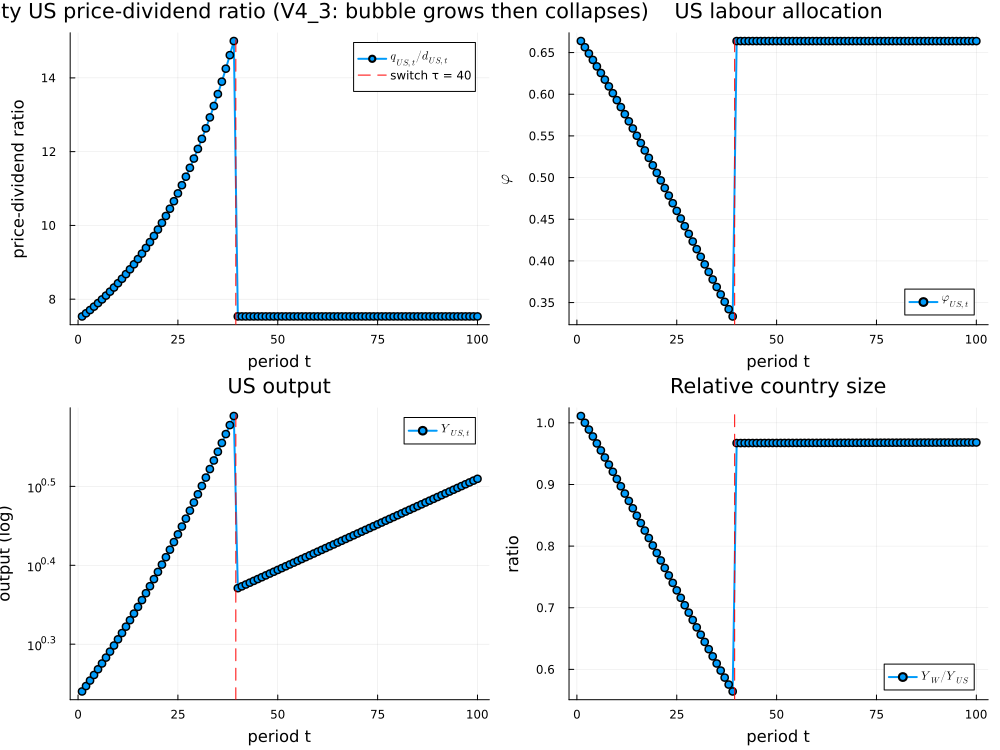

In [4]:
T = length(sim)
tt = 1:T

qd_path  = [s.q_US/s.d_US for s in sim]
QD_path  = [s.Q_US/(s.N_US*s.d_US) for s in sim]
φ_path   = [s.φ_US for s in sim]
Y_path   = [s.Y_US for s in sim]
rel_path = [s.Y_W/s.Y_US for s in sim]

switch_x = τ_switch - 0.5

p1 = plot(tt, qd_path, lw=2, marker=:circle, label=L"q_{US,t}/d_{US,t}",
          xlabel="period t", ylabel="price-dividend ratio",
          title="Per-variety US price-dividend ratio (V4_3: bubble grows then collapses)")
vline!(p1, [switch_x], ls=:dash, color=:red, label="switch τ = $τ_switch")

p2 = plot(tt, φ_path, lw=2, marker=:circle, label=L"\varphi_{US,t}",
          xlabel="period t", ylabel=L"\varphi",
          title="US labour allocation")
vline!(p2, [switch_x], ls=:dash, color=:red, label="")

p3 = plot(tt, Y_path, lw=2, marker=:circle, label=L"Y_{US,t}",
          xlabel="period t", ylabel="output (log)", yscale=:log10,
          title="US output")
vline!(p3, [switch_x], ls=:dash, color=:red, label="")

p4 = plot(tt, rel_path, lw=2, marker=:circle, label=L"Y_W/Y_{US}",
          xlabel="period t", ylabel="ratio",
          title="Relative country size")
vline!(p4, [switch_x], ls=:dash, color=:red, label="")

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 750))


## 3. Portfolio Policies and V4_3 Accounting Across the Switch

The primary V4_3 bond unknown is $\theta_{US,t}^*$ (RoW US-bond demand,
positive); $\theta_t$ (US household issuance, negative) is recovered.
The IPO transfer $\mathcal I_{US,t}, \mathcal I_{W,t}$
(V4_3 eq. `country_ipo_transfer`) is also displayed.


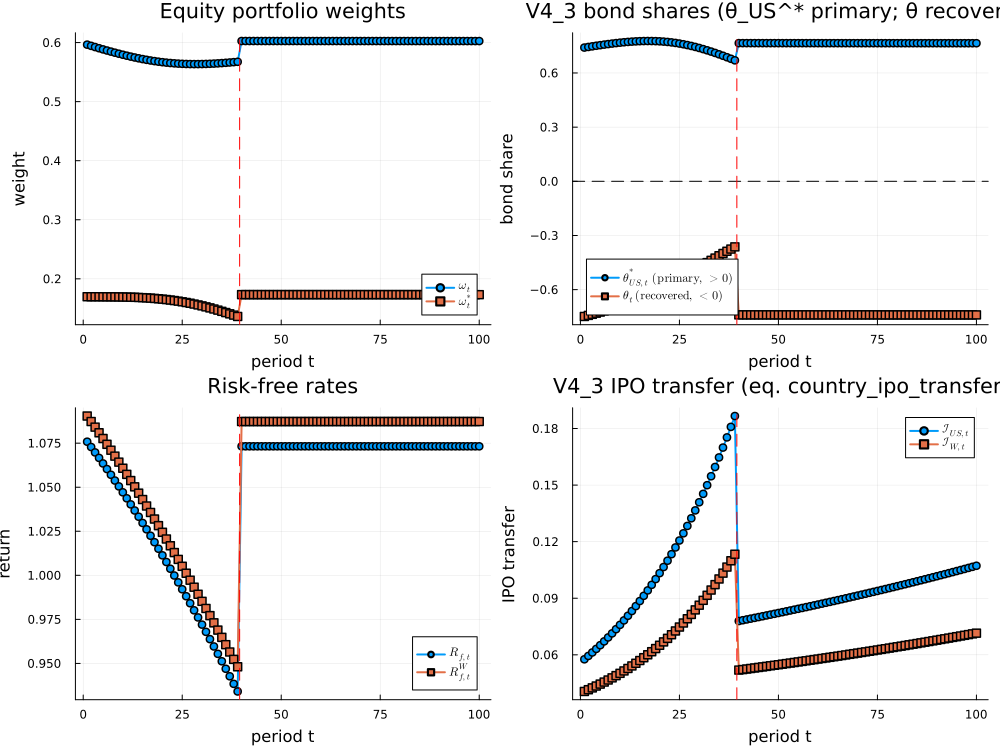

In [5]:
ω_path   = [s.ω         for s in sim]
ωs_path  = [s.ω_star    for s in sim]
θ_path   = [s.θ         for s in sim]
θUs_path = [s.θ_US_star for s in sim]
Rf_path  = [s.R_f       for s in sim]
RfW_path = [s.R_f_W     for s in sim]
I_US_path= [s.I_US      for s in sim]
I_W_path = [s.I_W       for s in sim]

p1 = plot(tt, ω_path, lw=2, marker=:circle, label=L"\omega_t",
          xlabel="period t", ylabel="weight",
          title="Equity portfolio weights")
plot!(p1, tt, ωs_path, lw=2, marker=:square, label=L"\omega_t^*")
vline!(p1, [switch_x], ls=:dash, color=:red, label="")

p2 = plot(tt, θUs_path, lw=2, marker=:circle,
          label=L"\theta_{US,t}^*\;(\mathrm{primary},\,> 0)",
          xlabel="period t", ylabel="bond share",
          title="V4_3 bond shares (θ_US^* primary; θ recovered)")
plot!(p2, tt, θ_path, lw=2, marker=:square,
      label=L"\theta_t\;(\mathrm{recovered},\,< 0)")
hline!(p2, [0.0], ls=:dash, color=:black, label="")
vline!(p2, [switch_x], ls=:dash, color=:red, label="")

p3 = plot(tt, Rf_path, lw=2, marker=:circle, label=L"R_{f,t}",
          xlabel="period t", ylabel="return",
          title="Risk-free rates")
plot!(p3, tt, RfW_path, lw=2, marker=:square, label=L"R_{f,t}^W")
vline!(p3, [switch_x], ls=:dash, color=:red, label="")

p4 = plot(tt, I_US_path, lw=2, marker=:circle, label=L"\mathcal{I}_{US,t}",
          xlabel="period t", ylabel="IPO transfer",
          title="V4_3 IPO transfer (eq. country_ipo_transfer)")
plot!(p4, tt, I_W_path, lw=2, marker=:square, label=L"\mathcal{I}_{W,t}")
vline!(p4, [switch_x], ls=:dash, color=:red, label="")

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 750))


## 4. Stochastic Sample Path (Monte Carlo)

Sample switch dates: [4, 24, 5, 6, 4]


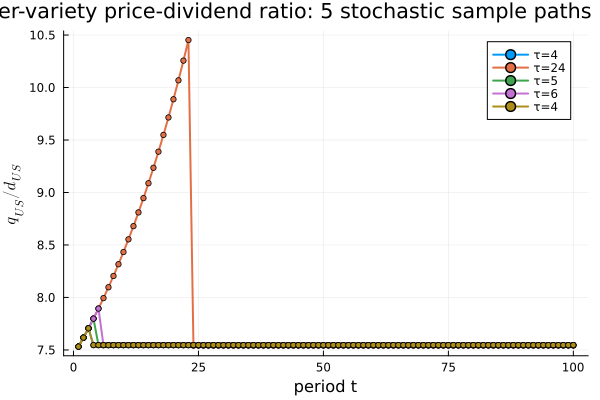

In [6]:
Random.seed!(42)

function simulate_one_path(p::ProductionParams, result, T::Int=p.T_max)
    z = :u
    τ = T + 1
    for t in 1:T
        if z == :u && rand() > p.π_persist
            τ = t; z = :b; break
        end
    end
    return build_switch_path(result, τ), τ
end

# 5 sample paths
paths = Vector{Vector{NamedTuple}}(); switches = Int[]
for _ in 1:5
    sim_path, τ = simulate_one_path(p, result)
    push!(paths, sim_path); push!(switches, τ)
end

println("Sample switch dates: ", switches)

p1 = plot(xlabel="period t", ylabel=L"q_{US}/d_{US}",
          title="Per-variety price-dividend ratio: 5 stochastic sample paths (V4_3)")
for (i, sim_path) in enumerate(paths)
    qd = [s.q_US/s.d_US for s in sim_path]
    τ = switches[i]
    plot!(p1, 1:length(sim_path), qd, lw=2, marker=:circle, ms=3, label="τ=$τ")
end
p1


## 5. Deterministic Switch-Path Plot for Export

The four standard baseline figures (price-dividend ratios, output,
relative size, V4_3 portfolio shares) are built here and saved to
`outputs_v43/` in §6.


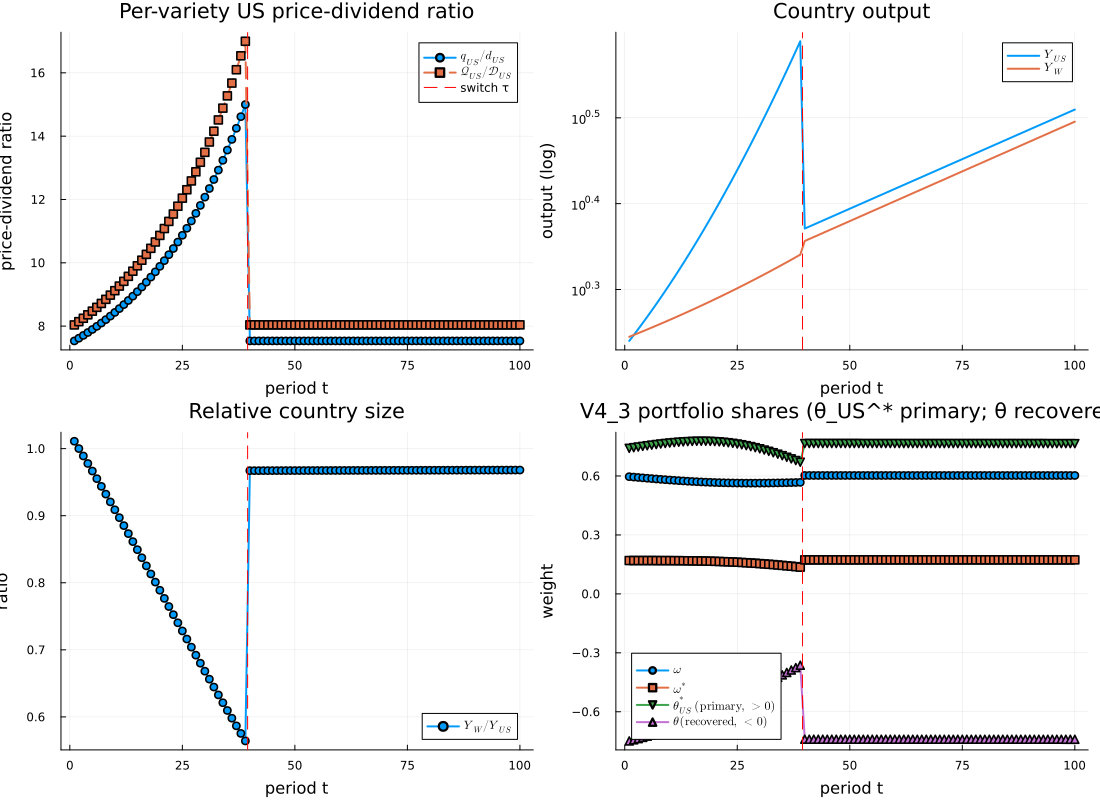

In [7]:
# Standard baseline figures (saved in §6)
fig_pd = plot(tt, qd_path, lw=2, marker=:circle, label=L"q_{US}/d_{US}",
          xlabel="period t", ylabel="price-dividend ratio",
          title="Per-variety US price-dividend ratio")
plot!(fig_pd, tt, QD_path, lw=2, marker=:square, label=L"\mathcal{Q}_{US}/\mathcal{D}_{US}", ls=:dash)
vline!(fig_pd, [switch_x], ls=:dash, color=:red, label="switch τ")

fig_Y = plot(tt, Y_path, lw=2, label=L"Y_{US}", yscale=:log10,
          xlabel="period t", ylabel="output (log)", title="Country output")
plot!(fig_Y, tt, [s.Y_W for s in sim], lw=2, label=L"Y_W")
vline!(fig_Y, [switch_x], ls=:dash, color=:red, label="")

fig_rel = plot(tt, rel_path, lw=2, marker=:circle, label=L"Y_W/Y_{US}",
          xlabel="period t", ylabel="ratio", title="Relative country size")
vline!(fig_rel, [switch_x], ls=:dash, color=:red, label="")

fig_port = plot(tt, ω_path, lw=2, marker=:circle, label=L"\omega",
          xlabel="period t", ylabel="weight",
          title="V4_3 portfolio shares (θ_US^* primary; θ recovered)")
plot!(fig_port, tt, ωs_path, lw=2, marker=:square, label=L"\omega^*")
plot!(fig_port, tt, θUs_path, lw=2, marker=:dtriangle,
      label=L"\theta_{US}^*\,(\mathrm{primary},\,> 0)")
plot!(fig_port, tt, θ_path, lw=2, marker=:utriangle,
      label=L"\theta\,(\mathrm{recovered},\,< 0)")
vline!(fig_port, [switch_x], ls=:dash, color=:red, label="")

plot(fig_pd, fig_Y, fig_rel, fig_port, layout=(2,2), size=(1100, 800))


## 6. Export Baseline Artifacts to `outputs_v43/`

Folds in the former `scripts/run_v9_baseline.jl` pipeline: writes the
three CSVs (V4_3 25-column schema with `I_US, I_W, Psi`), saves the four
standard PNG figures, and writes + prints a residual report including the
V4_3 output identity $Y = e + \mathcal D - \mathcal I$ and the
$\Psi_t > 0$ check (`ass_regular_kernel`, line 1145).


In [8]:
# ── CSV exports ──
open(joinpath(OUTDIR, "simulation_path.csv"), "w") do io
    write(io, "t,regime,phi_US,phi_W,q_US,d_US,q_W,d_W,Q_US,Q_W,e_US,e_W,Y_US,Y_W,N_US,N_W,omega,omega_star,theta_US_star,theta,R_f,R_f_W,I_US,I_W,Psi\n")
    for r in sim
        write(io, "$(r.t),$(r.regime),$(r.φ_US),$(r.φ_W),$(r.q_US),$(r.d_US),$(r.q_W),$(r.d_W),$(r.Q_US),$(r.Q_W),$(r.e_US),$(r.e_W),$(r.Y_US),$(r.Y_W),$(r.N_US),$(r.N_W),$(r.ω),$(r.ω_star),$(r.θ_US_star),$(r.θ),$(r.R_f),$(r.R_f_W),$(r.I_US),$(r.I_W),$(r.Psi)\n")
    end
end
println("✓ Saved: " * joinpath(OUTDIR, "simulation_path.csv"))

open(joinpath(OUTDIR, "bgp_solution.csv"), "w") do io
    write(io, "t,N_US,N_W,phi_US,phi_W,omega,omega_star,theta_US_star,theta,R_f,R_f_W,q_US,d_US,Q_US,Q_W,Y_US,Y_W,e_US,e_W,I_US,I_W,R_US,R_W,R_A,G_N_US,G_N_W,Psi,converged,resnorm\n")
    for (t, b) in enumerate(result.bgp_seq)
        write(io, "$(t-1),$(b.N_US),$(b.N_W),$(b.φ_US),$(b.φ_W),$(b.ω),$(b.ω_star),$(b.θ_US_star),$(b.θ),$(b.R_f),$(b.R_f_W),$(b.q_US),$(b.d_US),$(b.Q_US),$(b.Q_W),$(b.Y_US),$(b.Y_W),$(b.e_US),$(b.e_W),$(b.I_US),$(b.I_W),$(b.R_US),$(b.R_W),$(b.R_A),$(b.G_N_US),$(b.G_N_W),$(b.Psi),$(b.converged),$(b.residual_norm)\n")
    end
end
println("✓ Saved: " * joinpath(OUTDIR, "bgp_solution.csv"))

open(joinpath(OUTDIR, "unbalanced_branch_solution.csv"), "w") do io
    write(io, "t,N_US,N_W,phi_US,phi_W,omega,omega_star,theta_US_star,theta,R_f,R_f_W,q_US,d_US,Q_US,Q_W,Y_US,Y_W,e_US,e_W,I_US,I_W,Psi,resnorm\n")
    for s in result.u_path
        write(io, "$(s.t),$(s.N_US),$(s.N_W),$(s.φ_US),$(s.φ_W),$(s.ω),$(s.ω_star),$(s.θ_US_star),$(s.θ),$(s.R_f),$(s.R_f_W),$(s.q_US),$(s.d_US),$(s.Q_US),$(s.Q_W),$(s.Y_US),$(s.Y_W),$(s.e_US),$(s.e_W),$(s.I_US),$(s.I_W),$(s.Psi),$(s.residual_norm)\n")
    end
end
println("✓ Saved: " * joinpath(OUTDIR, "unbalanced_branch_solution.csv"))

# ── Figure exports ──
savefig(fig_pd,   joinpath(OUTDIR, "price_dividend_ratios.png"))
savefig(fig_Y,    joinpath(OUTDIR, "output_paths.png"))
savefig(fig_rel,  joinpath(OUTDIR, "relative_country_size.png"))
savefig(fig_port, joinpath(OUTDIR, "portfolio_shares.png"))
println("✓ Saved 4 PNG figures in ", OUTDIR)


✓ Saved: outputs_v43/simulation_path.csv
✓ Saved: outputs_v43/bgp_solution.csv
✓ Saved: outputs_v43/unbalanced_branch_solution.csv
✓ Saved 4 PNG figures in outputs_v43


In [9]:
# ── Residual report (printed and saved) ──
function write_residual_report(io)
    write(io, "V4_3 PRODUCTION-ECONOMY RESIDUAL REPORT\n")
    write(io, "═══════════════════════════════════════════\n\n")
    @printf(io, "T_max = %d   common_world_growth = %s\n", result.params.T_max, result.params.common_world_growth)
    @printf(io, "Calibrated ν_b = %.6f\n", result.params.ν_b)
    @printf(io, "u-branch converged = %s   max ‖F_u‖ = %.2e\n",
            result.branch_converged, result.max_u_residual)
    @printf(io, "max BGP residual = %.2e\n\n", result.max_bgp_residual)
    write(io, "BGP residuals (per switch date):\n")
    for (t, b) in enumerate(result.bgp_seq)
        @printf(io, "  t=%2d  ‖F‖=%.2e  converged=%s  Ψ=%.4e\n",
                t-1, b.residual_norm, b.converged, b.Psi)
    end
    write(io, "\nu-path residuals:\n")
    for s in result.u_path
        @printf(io, "  t=%2d  ‖F‖=%.2e  Ψ=%.4e\n", s.t, s.residual_norm, s.Psi)
    end
    write(io, "\nMarket-clearing checks:\n")
    max_us = 0.0; max_w = 0.0; max_b = 0.0; max_id = 0.0
    max_yid_us = 0.0; max_yid_w = 0.0
    for s in result.u_path
        us_err = abs(s.Q_US - s.ω*s.S - s.ω_star*s.S_star)
        w_err  = abs(s.Q_W - (1-s.ω)*s.S - (1-s.ω_star)*s.S_star)
        b_err  = abs(s.θ*s.A + s.θ_US_star*s.A_star)
        id_err = abs(s.Q_US + s.Q_W - (result.params.β*s.e_US + (result.params.β+result.params.χ)/(1+result.params.χ)*s.e_W))
        yid_us = abs(s.Y_US - (s.e_US + s.N_US*s.d_US - s.I_US))
        yid_w  = abs(s.Y_W  - (s.e_W  + s.N_W *s.d_W  - s.I_W))
        max_us = max(max_us, us_err); max_w = max(max_w, w_err)
        max_b  = max(max_b, b_err);   max_id = max(max_id, id_err)
        max_yid_us = max(max_yid_us, yid_us); max_yid_w = max(max_yid_w, yid_w)
    end
    @printf(io, "  US stock-clearing max:        %.2e\n", max_us)
    @printf(io, "  RoW stock-clearing max:       %.2e\n", max_w)
    @printf(io, "  Bond-clearing max:            %.2e\n", max_b)
    @printf(io, "  Aggregate-cap identity max:   %.2e\n", max_id)
    @printf(io, "  V4_3 Y=e+D-I (US) max:        %.2e\n", max_yid_us)
    @printf(io, "  V4_3 Y=e+D-I (RoW) max:       %.2e\n", max_yid_w)

    write(io, "\nV4_3 regularity checks:\n")
    @printf(io, "  ass_regular_kernel Ψ_t > 0:       %s   (min Ψ = %.4e)\n",
            result.diagnostics.psi_ok, result.diagnostics.psi_min)
    @printf(io, "  ass_interior_equity_weights:      %s   (min slack = %.4e)\n",
            result.diagnostics.equity_weights_ok, result.diagnostics.equity_weight_min)

    write(io, "\nTheorem 1 diagnostics (V4_3 thm_bubble_characterization):\n")
    @printf(io, "  Σ d^u/q^u = %.6f (cond 1a converges: %s)\n",
            result.diagnostics.cum_1a[end], result.diagnostics.cond_1a_converges)
    @printf(io, "  Σ branch  = %.6f (cond 1b converges: %s)\n",
            result.diagnostics.cum_1b[end], result.diagnostics.cond_1b_converges)
    @printf(io, "  BUBBLE EXISTS:                %s\n", result.diagnostics.bubble_exists)
    @printf(io, "  Total leakage Σ a_t:          %.6f\n", result.diagnostics.cum_a_t[end])
end

write_residual_report(stdout)
open(io -> write_residual_report(io), joinpath(OUTDIR, "residual_report.txt"), "w")
println("\n✓ Saved: " * joinpath(OUTDIR, "residual_report.txt"))


V4_3 PRODUCTION-ECONOMY RESIDUAL REPORT
═══════════════════════════════════════════

T_max = 100   common_world_growth = true
Calibrated ν_b = 0.081719
u-branch converged = true   max ‖F_u‖ = 3.94e-08
max BGP residual = 7.50e-10

BGP residuals (per switch date):
  t= 0  ‖F‖=4.61e-10  converged=true  Ψ=9.8806e-01
  t= 1  ‖F‖=1.02e-10  converged=true  Ψ=9.8806e-01
  t= 2  ‖F‖=5.10e-12  converged=true  Ψ=9.8806e-01
  t= 3  ‖F‖=2.17e-10  converged=true  Ψ=9.8806e-01
  t= 4  ‖F‖=7.50e-10  converged=true  Ψ=9.8806e-01
  t= 5  ‖F‖=4.44e-16  converged=true  Ψ=9.8807e-01
  t= 6  ‖F‖=3.54e-16  converged=true  Ψ=9.8807e-01
  t= 7  ‖F‖=3.89e-16  converged=true  Ψ=9.8807e-01
  t= 8  ‖F‖=1.65e-16  converged=true  Ψ=9.8808e-01
  t= 9  ‖F‖=3.27e-16  converged=true  Ψ=9.8808e-01
  t=10  ‖F‖=2.32e-16  converged=true  Ψ=9.8809e-01
  t=11  ‖F‖=3.02e-16  converged=true  Ψ=9.8809e-01
  t=12  ‖F‖=6.81e-17  converged=true  Ψ=9.8810e-01
  t=13  ‖F‖=4.26e-16  converged=true  Ψ=9.8811e-01
  t=14  ‖F‖=2.22e-16  c

## Summary

- The deterministic switch path shows the V4_3 mechanism: $q^u/d^u$
  rises along the u-branch and stabilises after the switch
  (V4_3 Proposition `prop_no_bubble_absorbing_branch`).
- Random draws of the regime process show the heterogeneity in switch
  dates and the resulting price-dividend trajectories.
- §6 exports the full baseline artifact set to `outputs_v43/`: three CSVs
  (V4_3 25-column schema with $\theta_{US}^*$ primary, $\theta$ recovered,
  and $\mathcal I_{US}, \mathcal I_W, \Psi$), four PNG figures, and a
  residual report confirming the V4_3 output identity
  $Y = e + \mathcal D - \mathcal I$ at machine precision and
  $\Psi_t > 0$ (`ass_regular_kernel`).
- This consolidates the former `scripts/run_v9_baseline.jl` driver into
  the notebook workflow; run headlessly with
  `jupyter nbconvert --to notebook --execute 05_v9_simulation_path.ipynb`.
